# Tutorial: Using QuboSolver for the **Set Partitioning Problem**

In this tutorial, we illustrate the use of **QuboSolver** on a classical combinatorial optimization case: the **Set Partitioning Problem** (SPP).  

This problem is a **fundamental benchmark** in operations research and combinatorial optimization, with applications such as crew scheduling, political redistricting, combinatorial design, and resource allocation. Its simplicity and broad applicability make it an **ideal benchmark** for both classical and quantum-inspired optimization methods.

---

### References

| Citation | Details |
|---------|---------|
| Garfinkel & Nemhauser (1969) | *The set-partitioning problem: set covering with equality constraints.* Operations Research. |
| Glover, Kochenberger & Hennig (2022) | *Quantum bridge analytics I: a tutorial on formulating and using QUBO models.* Annals of Operations Research. |
| Cacao et al. (2023) | *Set partitioning problem in a quantum context*: tight QUBO, reductions & VQE. Optimization Online. |
| Lewis et al. (2008) | QUBO approach to large-scale set partitioning applications. |
| Sato & Izunaga (2017) | SPP in branch-and-price formulations for modularity maximization. [arXiv:1705.02961](https://arxiv.org/abs/1705.02961) |

---

## Problem definition

The **Set Partitioning Problem** (SPP) is defined as follows:

- We have a universe of **items** $I$.  
- We have a collection of **subsets** (or "partitions") $P$. Each subset $p \in P$ covers a subset of items $I_p \subseteq I$.  
- Each subset $p$ has a **cost** $w_p \geq 0$.  

**Objective**: choose exactly one covering subset for each item (i.e., such that each item is in exactly one chosen subset), minimizing the total cost.

---

## Integer Linear Programming (ILP) formulation

We introduce binary decision variables:

- $x_p \in \{0,1\}$: equals 1 if subset $p \in P$ is chosen, 0 otherwise.

The ILP model:

$$
\begin{align}
\min \quad & \sum_{p \in P} w_p \, x_p \\
\text{s.t.} \quad & \sum_{p : i \in I_p} x_p = 1 \quad && \forall i \in I \quad \text{(each item exactly once)} \\
& x_p \in \{0,1\} \quad && \forall p \in P.
\end{align}
$$

---

We now introduce a toy instance that will guide this tutorial.


# Toy Instance: Set Partitioning Problem (3 items, 7 subsets)

We consider a compact **SPP** with **3 items** and **7 subsets**, deliberately designed so that several distinct exact covers exist.

- Items:  
  $ I = \{1,2,3\}. $

- Subsets (decision variables):  
  $ P = \{A,B,C,D,E,F,G\}. $

- Each subset $p \in P$ covers a set of items $I_p \subseteq I$ and has a cost $w_p \ge 0$.

---

## Data

### Subsets and costs

| Subset | Items covered $I_p$ | Cost $w_p$ |
|:------:|:---------------------|:----------:|
| $A$ | $\{1\}$ | $1$ |
| $B$ | $\{2\}$ | $1$ |
| $C$ | $\{3\}$ | $2$ |
| $D$ | $\{1,2\}$ | $3$ |
| $E$ | $\{1\}$ | $3$ |
| $F$ | $\{2\}$ | $4$ |
| $G$ | $\{1,3\}$ | $1$ |

> Intuition:  
> - Item $1$ can be covered by $A$, by $D$ (together with item $2$), by $E$, or by $G$ (together with item $3$).  
> - Item $2$ can be covered by $B$, by $D$, or by $F$.  
> - Item $3$ can be covered by $C$ or by $G$.

---

## Incidence matrix

$$
A =
\begin{bmatrix}
1 & 0 & 0 & 1 & 1 & 0 & 1 \\\\
0 & 1 & 0 & 1 & 0 & 1 & 0 \\\\
0 & 0 & 1 & 0 & 0 & 0 & 1
\end{bmatrix}
$$

- Rows correspond to items $1,2,3$.  
- Columns correspond to subsets $A,B,C,D,E,F,G$.

---

## Feasible exact covers

Some feasible partitions of $I$ are:

- **All singletons:** $\{A,B,C\}$  
- **Using $D$ for $(1,2)$:** $\{D,C\}$  
- **Using $G$ for $(1,3)$:** $\{G,B\}$ or $\{G,F\}$  

---

We will now solve this instance to **optimality** using the ILP formulation with CPLEX.

In [ ]:
# --- SPP (7 variables, 3 items) solved with cplex.Cplex ---

import numpy as np
from cplex_model import create_cplex_model, solve_cplex, populate_solution_pool

# -------------------------------
# 0) Instance data (7 vars / 3 items)
# -------------------------------
items   = ["1","2","3"]
subsets = ["A","B","C","D","E","F","G"]   # 7 variables
# Costs w_p
w = np.array([1, 1, 2, 3, 3, 4, 1], dtype=float)  # A..E=2, F=3, G=3
# Incidence matrix A (rows = items, cols = subsets)
# rows: items 1..3 ; cols: A..G
A = np.array([
    [1,0,0,1,1,0,1],  # item 1 in A,F,G
    [0,1,1,1,0,1,0],  # item 2 in B,E,F
    [0,0,0,0,0,0,1],  # item 3 in C,G
], dtype=float)

I, P = A.shape # noqa: E741
assert P == len(subsets) == 7 and I == len(items) == 3

# -------------------------------
# 1) Build CPLEX model
# -------------------------------
x_names = [f"x_{p}" for p in subsets]
mdl = create_cplex_model(x_names, P, w, I, A)


# -------------------------------
# 2) Solve
# -------------------------------
best_ilp_cost = solve_cplex(mdl, x_names, subsets, items, I, P, A, w)

# -------------------------------
# 3) Populate solution pool (unique, sorted)
# -------------------------------
populate_solution_pool(mdl, x_names, subsets, A)


=== OPTIMAL SOLUTION (SPP, 3 vars) ===
Status   : integer optimal solution
Objective: 2.0
--- Optimal ---
Variables: A, B, C, D, E, F, G
Optimal Bitstring        : 0100001
Selected subsets : ['B', 'G']
ILP cost         : 2.0
Feasibility vio. : 0
Coverage:
  Item 1 covered by: ['G']
  Item 2 covered by: ['B']
  Item 3 covered by: ['G']

Execution time: 0.0034 s

=== SOLUTION POOL (unique = 3,         total CPLEX pool = 3) ===

-- Solution #1 --
Objective: 2.0
Bitstring: 0100001 (order: A,B,C,D,E,F,G)
Selected : ['B', 'G']
Feas.Vio.: 0

-- Solution #2 --
Objective: 3.0
Bitstring: 0010001 (order: A,B,C,D,E,F,G)
Selected : ['C', 'G']
Feas.Vio.: 0

-- Solution #3 --
Objective: 5.0
Bitstring: 0000011 (order: A,B,C,D,E,F,G)
Selected : ['F', 'G']
Feas.Vio.: 0


## QUBO Reformulation of the Set Partitioning Problem

We reformulate the **Set Partitioning Problem (SPP)** as a **QUBO (Quadratic Unconstrained Binary Optimization)**, suitable for quantum and hybrid solvers.

---

### 1) Decision variables

For each subset \(p \in P\):

$$
x_p \in \{0,1\}, 
\qquad 
x_p = 1 \;\;\Leftrightarrow\;\; p \text{ is selected}.
$$

---

### 2) Original objective

$$
\min \;\; \sum_{p \in P} w_p \, x_p .
$$

This part is linear and can be included directly in the QUBO.

---

### 3) Encoding of exact-cover constraints

Each item must be covered exactly once:

$$
\sum_{p : i \in I_p} x_p \;=\; 1 \quad \forall i \in I .
$$

We encode this as a quadratic penalty:

$$
\Big( \sum_{p : i \in I_p} x_p - 1 \Big)^2 ,
$$

which is zero iff item \(i\) is covered by exactly one selected subset.

---

### 4) Complete QUBO

Let \(M>0\) be a penalty weight.  
The full QUBO objective is:

$$
Q(x) \;=\;
\sum_{p \in P} w_p \, x_p
\;+\;
M \sum_{i \in I}
\Big( \sum_{p : i \in I_p} x_p - 1 \Big)^2 .
$$

For the toy instance, we set

$$
M = 2.5 ,
$$

a simple value large enough to enforce feasibility.

---

## Explicit QUBO for the 7-variable SPP instance \((A,B,C,D,E,F,G)\)

With the incidence
- item \(1\): \(A,D,E,G\)  
- item \(2\): \(B,D,F\)  
- item \(3\): \(C,G\)

and costs  
\(w_A=1,\; w_B=1,\; w_C=2,\; w_D=3,\; w_E=3,\; w_F=4,\; w_G=1\),

---

### Matrix form (order \(A,B,C,D,E,F,G\))

We write \(Q(x)=x^\top Q x + \text{const}\) with a symmetric matrix \(Q\) whose off-diagonal entries are **half** of the quadratic coefficients and whose diagonal equals the linear terms (after using \(x_p^2=x_p\)):

$$
Q =
\begin{pmatrix}
-1.5 & 0   & 0   & 2.5 & 2.5 & 0   & 2.5 \\
0    & -1.5& 2.5 & 2.5 & 0   & 2.5 & 0   \\
0    & 2.5 & -0.5& 2.5 & 0   & 2.5 & 0   \\
2.5  & 2.5 & 2.5 & -2  & 2.5 & 2.5 & 2.5 \\
2.5  & 0   & 0   & 2.5 & 0.5 & 0   & 2.5 \\
0    & 2.5 & 2.5 & 2.5 & 0   & 1.5 & 0   \\
2.5  & 0   & 0   & 2.5 & 2.5 & 0   & -4
\end{pmatrix}.
$$

(The constant term is irrelevant for optimization.)

=== QUBO (polynomial form) ===
Chosen M = 2.5

Constant term:
  7.5

Linear part  Σ h_p x_p :
  -1.5 x_A - 1.5 x_B - 0.5 x_C - 2 x_D + 0.5 x_E + 1.5 x_F - 4 x_G

Quadratic part  Σ_{p<q} J_pq x_p x_q (J_pq = 2·Q_pq) :
  5 x_A x_D + 5 x_A x_E + 5 x_A x_G + 5 x_B x_C + 5 x_B x_D + 5 x_B x_F + 5 x_C x_D + 5 x_C x_F + 5 x_D x_E + 5 x_D x_F + 5 x_D x_G + 5 x_E x_G

Q matrix (reference):
[[-1.5  0.   0.   2.5  2.5  0.   2.5]
 [ 0.  -1.5  2.5  2.5  0.   2.5  0. ]
 [ 0.   2.5 -0.5  2.5  0.   2.5  0. ]
 [ 2.5  2.5  2.5 -2.   2.5  2.5  2.5]
 [ 2.5  0.   0.   2.5  0.5  0.   2.5]
 [ 0.   2.5  2.5  2.5  0.   1.5  0. ]
 [ 2.5  0.   0.   2.5  2.5  0.  -4. ]]


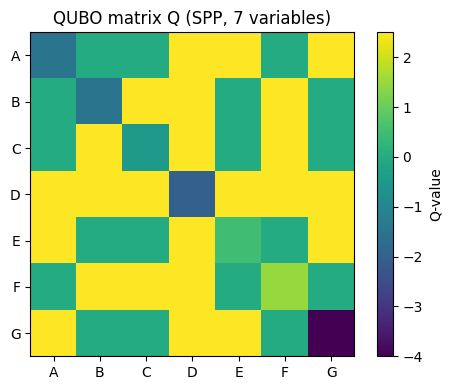

In [ ]:
# --- Restore the intended 3x6 incidence for the toy instance ---
# rows = items 1..3, cols = subsets A..G
import matplotlib.pyplot as plt
from helpers import _fmt, _join_terms

A_bin = np.array([
    [1,0,0,1,1,0,1],  # item 1 in A,F,G
    [0,1,1,1,0,1,0],  # item 2 in B,E,F
    [0,0,0,0,0,0,1],  # item 3 in C,G
], dtype=float)

assert A_bin.shape == (3, 7)
assert subsets == ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# --- Build Q from the correct incidence (parameterizable M) ---
M = 2.5  # change freely
I, P = A_bin.shape # noqa: E741
deg = A_bin.sum(axis=0)              # how many items each subset covers
B   = A_bin.T @ A_bin                # co-cover counts
Q   = np.diag(w) + M * (B - 2.0 * np.diag(deg))
const_offset = float(M * I)



lin_terms  = [(Q[i, i], f"x_{subsets[i]}") for i in range(P)]
quad_terms = [(2.0 * Q[i, j], f"x_{subsets[i]} x_{subsets[j]}")
              for i in range(P) for j in range(i + 1, P)]

print("=== QUBO (polynomial form) ===")
print(f"Chosen M = {_fmt(M)}\n")
print("Constant term:")
print(f"  {_fmt(const_offset)}\n")
print("Linear part  Σ h_p x_p :")
print("  " + _join_terms(lin_terms) + "\n")
print("Quadratic part  Σ_{p<q} J_pq x_p x_q (J_pq = 2·Q_pq) :")
print("  " + _join_terms(quad_terms) + "\n")

print("Q matrix (reference):")
np.set_printoptions(precision=3, suppress=True)
print(Q)

# --- Heatmap ---
plt.figure(figsize=(5,4))
plt.imshow(Q)
plt.colorbar(label="Q-value")
plt.title("QUBO matrix Q (SPP, 7 variables)")
plt.xticks(range(P), subsets)
plt.yticks(range(P), subsets)
plt.tight_layout()
plt.show()


## Solving the SPP QUBO with an Adiabatic Algorithm

We now solve the Set Partitioning Problem using the `QuboSolver` with the **adiabatic pulse shaping method**.  
We keep the solver **default configuration parameters**, in order to directly observe the solutions produced by this baseline quantum-inspired approach.

Before running the solver, we define a few **helper functions** for visualization and reporting.  
These will allow us to reuse the same concise summary and binary coverage plots for all solution methods.


In [ ]:
from helpers import summarize_solution, show_binary_status

The goal now is to examine how enabling **pre-processing** and **post-processing** steps can influence the **quality and feasibility** of the solutions returned.

By comparing runs **with** and **without** these steps, we can clearly observe their practical impact on solution quality.

=== Adiabatic (no pre/post-processing) ===
Optimal bitstring (order: A, B, C, D, E, F, G): 0000001
Selected variables            : ['G']
ILP objective (Σ w_p x_p)     : 1
Feasibility (exact cover)     :         Infeasible ❌ (violation=1)
QUBO objective (x^T Q x + cst): 3.5
Gap to ILP optimum           : N/A (infeasible)


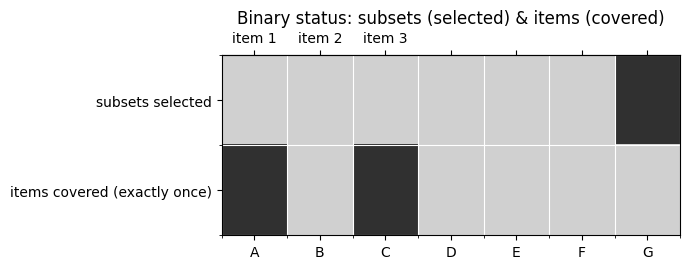

=== Adiabatic (with pre/post-processing) ===
Optimal bitstring (order: A, B, C, D, E, F, G): 0100001
Selected variables            : ['B', 'G']
ILP objective (Σ w_p x_p)     : 2
Feasibility (exact cover)     :         Feasible ✅
QUBO objective (x^T Q x + cst): 2
Gap to ILP optimum           : 0.00%  (opt = 2)


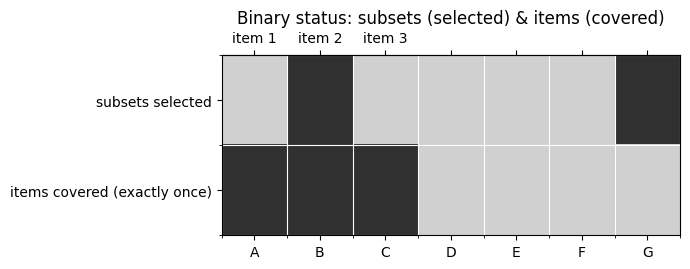

In [ ]:
# --- Adiabatic solves: compare WITHOUT vs WITH pre/post-processing ---

import numpy as np
import torch
from qubosolver import QUBOInstance
from qubosolver.data import QUBOSolution
from qubosolver.config import SolverConfig, PulseShapingConfig
from qubosolver.solver import QuboSolver
from qubosolver.qubo_types import PulseType

const_offset = float(globals().get('const_offset', 0.0))
P = len(subsets)

def run_adiabatic(do_preprocessing: bool, do_postprocessing: bool, label: str) -> tuple[dict, QUBOSolution]:
    """Run adiabatic solver with given (pre/post)-processing flags and report/visualize."""
    Qt = Q if isinstance(Q, torch.Tensor) else torch.tensor(Q, dtype=torch.float32)
    instance = QUBOInstance(Qt)

    cfg = SolverConfig(
        use_quantum=True,
        pulse_shaping=PulseShapingConfig(pulse_shaping_method=PulseType.ADIABATIC),
        do_preprocessing=do_preprocessing,
        do_postprocessing=do_postprocessing,
    )

    solver = QuboSolver(instance, cfg)
    _ = solver.embedding()        # optional
    sol = solver.solve()

    # pick best by solver's reported objective (on ORIGINAL Q)
    best_idx  = int(torch.argmin(sol.costs))
    best_bits = sol.bitstrings[best_idx].to(dtype=torch.int).cpu().numpy().astype(int)

    # textual summary (ILP objective, QUBO objective, feasibility, gap)
    summarize_solution(
        best_bits, subsets, A, w,
        Q=Q, const_offset=const_offset,
        best_ilp_cost=best_ilp_cost,
        label=label
    )

    # binary visualization (selected subsets / exact-cover status by item)
    show_binary_status(subsets, best_bits, items=None, A=A, item_rule="exactly_one")

    # return a compact dict (could be used to build a small comparison table later)
    ilp_val = float(np.dot(w, best_bits))
    gap_pct = (ilp_val - best_ilp_cost) / best_ilp_cost * 100.0
    return {
        "label": label,
        "bitstring": "".join(str(int(b)) for b in best_bits),
        "ilp_objective": ilp_val,
        "gap_pct": gap_pct,
    }, sol

# --- Run both scenarios ---
res_no_proc_adiabatic = run_adiabatic(False, False, "Adiabatic (no pre/post-processing)")

res_with_proc_adiabatic = run_adiabatic(True,  True,  "Adiabatic (with pre/post-processing)")

## Solving the SPP QUBO with the Optimized Pulse Algorithm
As we can se in the previous cell, the solution quality obtained by the custom regiter is poor. We will now see how an optimized pulse can enhance the quality of the problem solution.

We the Set Partitioning Problem using the **optimized pulse-shaping method**.

Compared to the adiabatic schedule, this approach adapts the pulse parameters during evolution and is expected to yield **better solution quality**.

As before, we will compare runs **with** and **without** pre/post-processing.

=== Optimized (no pre/post-processing) ===
Optimal bitstring (order: A, B, C, D, E, F, G): 0100001
Selected variables            : ['B', 'G']
ILP objective (Σ w_p x_p)     : 2
Feasibility (exact cover)     :         Feasible ✅
QUBO objective (x^T Q x + cst): 2
Gap to ILP optimum           : 0.00%  (opt = 2)


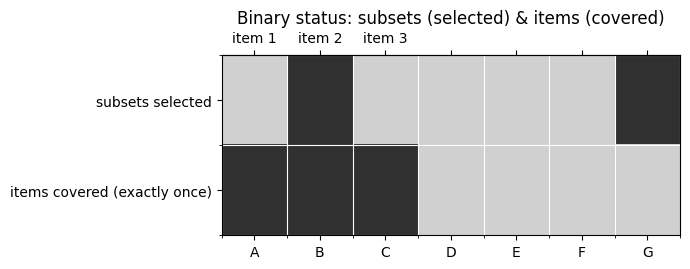

=== Optimized (with pre/post-processing) ===
Optimal bitstring (order: A, B, C, D, E, F, G): 0100001
Selected variables            : ['B', 'G']
ILP objective (Σ w_p x_p)     : 2
Feasibility (exact cover)     :         Feasible ✅
QUBO objective (x^T Q x + cst): 2
Gap to ILP optimum           : 0.00%  (opt = 2)


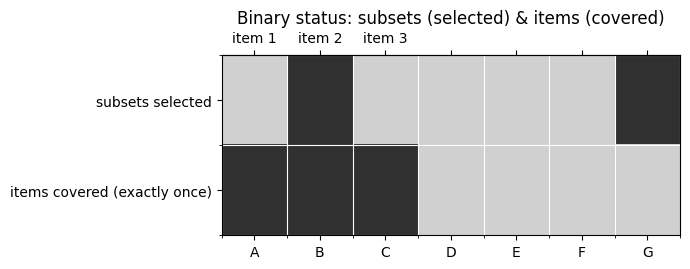

In [ ]:
# --- Optimized solves: compare WITHOUT vs WITH pre/post-processing ---

import numpy as np

const_offset = float(globals().get('const_offset', 0.0))
P = len(subsets)


def run_optimized(do_preprocessing: bool, do_postprocessing: bool, label: str) -> tuple[dict, QUBOSolution]:
    """Run OPTIMIZED pulse solver with given (pre/post)-processing flags and report/visualize."""
    Qt = Q if isinstance(Q, torch.Tensor) else torch.tensor(Q, dtype=torch.float32)
    instance = QUBOInstance(Qt)


    cfg = SolverConfig(
        use_quantum=True,
        n_calls=30,
        pulse_shaping=PulseShapingConfig(pulse_shaping_method=PulseType.OPTIMIZED),
        do_preprocessing=do_preprocessing,
        do_postprocessing=do_postprocessing,
    )

    solver = QuboSolver(instance, cfg)
    _ = solver.embedding()        # optional
    sol = solver.solve()

    # pick best by solver's reported objective (on ORIGINAL Q)
    best_idx  = int(torch.argmin(sol.costs))
    best_bits = sol.bitstrings[best_idx].to(dtype=torch.int).cpu().numpy().astype(int)

    # textual summary (ILP objective, QUBO objective, feasibility, gap if feasible)
    summarize_solution(
        best_bits, subsets, A, w,
        Q=Q, const_offset=const_offset,
        best_ilp_cost=best_ilp_cost,
        label=label
    )

    # binary visualization (selected subsets / exact-cover status by item)
    show_binary_status(subsets, best_bits, items=None, A=A, item_rule="exactly_one")

    # compact dict for quick comparison (gap only if feasible)
    ilp_val = float(np.dot(w, best_bits))
    viol = int(np.sum(np.abs((A @ best_bits) - 1)))
    if viol == 0:
        gap_pct = (ilp_val - best_ilp_cost) / best_ilp_cost * 100.0
        gap_str = f"{gap_pct:.2f}%"
    else:
        gap_str = "N/A"
    return {
        "label": label,
        "bitstring": "".join(str(int(b)) for b in best_bits),
        "ilp_objective": ilp_val,
        "gap": gap_str,
    }, sol

# --- Run both scenarios ---
res_no_proc_optimized   = run_optimized(False, False, "Optimized (no pre/post-processing)")
res_with_proc_optimized = run_optimized(True,  True,  "Optimized (with pre/post-processing)")

## Custom Embedding with a User-Defined Register

This custom register is implemented by the user (here via the `MysteriousEmbedder` class).
We will run the adiabatic solver again with this embedding and compare the results.

=== Adiabatic + Custom Embedder (with pre+post) ===
Optimal bitstring (order: A, B, C, E, F, G, I): 0100001
Selected variables            : ['B', 'I']
ILP objective (Σ w_p x_p)     : 2
Feasibility (exact cover)     :         Feasible ✅
QUBO objective (x^T Q x + cst): 2
Gap to ILP optimum           : 0.00%  (opt = 2)


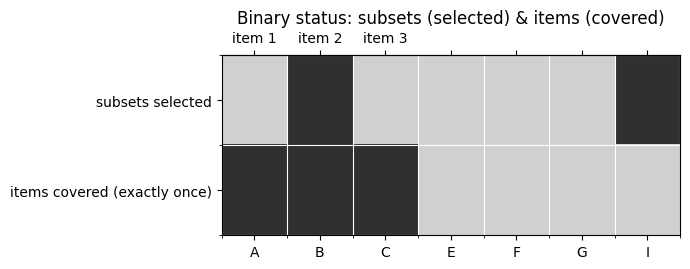

In [ ]:
# --- Adiabatic with custom freespace embedder + pre/post (one run) ---

import numpy as np

from example_use_cases.set_partitioning.embedder import SetPartitioningEmbedder

const_offset = float(globals().get('const_offset', 0.0))
P = len(subsets)

# QUBO instance
instance = QUBOInstance(Q if isinstance(Q, torch.Tensor) else torch.tensor(Q, dtype=torch.float32))

# Config : custom embedder SetPartitioningEmbedder + adiabatic + pre/post
cfg = SolverConfig.from_kwargs(
    use_quantum=True,
    embedding_method=SetPartitioningEmbedder,                 # <-- our class SetPartitioningEmbedder(BaseEmbedder)
    do_preprocessing=True,
    do_postprocessing=True,
    pulse_shaping=PulseShapingConfig(pulse_shaping_method=PulseType.ADIABATIC),
)

solver = QuboSolver(instance, cfg)

# Construct geometry via embedder
_ = solver.embedding()

# Solve (adiabatic, with pre/post)
solution = solver.solve()

# Best sample
best_idx  = int(torch.argmin(solution.costs))
best_bits = solution.bitstrings[best_idx].to(dtype=torch.int).cpu().numpy().astype(int)

# Summary + visualization
summarize_solution(
    best_bits, subsets, A, w,
    Q=Q, const_offset=const_offset,
    best_ilp_cost=best_ilp_cost,
    label="Adiabatic + Custom Embedder (with pre+post)"
)
show_binary_status(subsets, best_bits, items=None, A=A, item_rule="exactly_one")
